# Zentra — ML Modelling Notebook

**Scope:** Model training, comparison, hyperparameter tuning, evaluation, and export.  
Infrastructure (Supabase, MLflow, DVC) lives in `scripts/` — imported here, not defined here.

| Section | Content |
|---|---|
| 0 | Setup & imports |
| 1 | Load & validate data |
| 2 | Feature preparation & temporal split |
| 3 | Model comparison — 6 models head-to-head |
| 4 | Why LightGBM — analysis |
| 5 | LightGBM hyperparameter tuning (Optuna) |
| 6 | Prophet — per-location time-series |
| 7 | Ensemble: LightGBM + Prophet |
| 8 | Final evaluation & plots |
| 9 | Export — model, metrics, artefacts |

In [1]:
# Install all required packages 
# Run once; comment out after the first install.

!pip install lightgbm prophet xgboost scikit-learn mlflow dvc supabase \
             optuna shap matplotlib seaborn pandas numpy --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
# Core imports 

%matplotlib inline
import warnings, os, json, subprocess, time
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ML models
import lightgbm as lgb
import xgboost as xgb
from prophet import Prophet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Hyperparameter tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Feature importance
import shap

# MLflow
import mlflow
import mlflow.lightgbm
import mlflow.sklearn

# Supabase
from supabase import create_client, Client

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', font_scale=1.05)

BLUE, ORANGE, RED, GREEN, PURPLE = '#1a6bff', '#f59e0b', '#ef4444', '#22c55e', '#8b5cf6'
MODEL_COLORS = {
    'LightGBM':         BLUE,
    'XGBoost':          ORANGE,
    'RandomForest':     GREEN,
    'GradientBoosting': PURPLE,
    'Ridge':            '#6b7280',
    'Prophet':          RED,
}

SEED = 42
np.random.seed(SEED)

print(f'LightGBM   {lgb.__version__}')
print(f'XGBoost    {xgb.__version__}')
print(f'MLflow     {mlflow.__version__}')

LightGBM   4.6.0
XGBoost    3.2.0
MLflow     3.14.0


In [29]:
# Project paths 

ROOT = Path('../').resolve()
DATA = ROOT / 'data'
MASTER = DATA / 'master'
MODELS = ROOT / 'models';  MODELS.mkdir(exist_ok=True)
PLOTS = DATA / 'plots';   PLOTS.mkdir(parents=True, exist_ok=True)
REPORTS = ROOT / 'reports'; REPORTS.mkdir(exist_ok=True)

# Data files
MULTIDATE_CSV = MASTER / 'zentra_multidate_h3.csv'
PROPHET_CSV = MASTER / 'zentra_prophet_ready.csv'

print('Paths configured.')
print(f'  Data root: {DATA}')
print(f'  Models:    {MODELS}')

Paths configured.
  Data root: D:\Projects\Zentra\zentra-ml\data
  Models:    D:\Projects\Zentra\zentra-ml\models


In [30]:
df = pd.read_csv(MULTIDATE_CSV, parse_dates=['survey_date'])
df_prop = pd.read_csv(PROPHET_CSV,   parse_dates=['ds'])

print(f'LightGBM input : {df.shape}')
print(f'Prophet input : {df_prop.shape}')
print(f'Date range : {df["survey_date"].min().date()} → {df["survey_date"].max().date()}')
print(f'Unique locations : {df["location_id"].nunique()}')
print(df['pedestrians'].describe().to_frame().T)

LightGBM input : (3826, 63)
Prophet input : (3826, 51)
Date range : 2007-05-15 → 2025-10-15
Unique locations : 36
               count     mean      std   min      25%      50%      75%  \
pedestrians 3826.000 6226.209 5340.172 0.000 2604.500 4684.500 8182.500   

                  max  
pedestrians 50827.000  


In [31]:
def data_quality_report(name, frame, date_col=None):
    n_null = int(frame.isnull().sum().sum())
    print(f' {name}')
    print(f' Shape : {frame.shape[0]:,} x {frame.shape[1]}')
    print(f' Nulls : {n_null:,}  ({n_null / frame.size * 100:.2f}%)')
    if date_col and date_col in frame.columns:
        print(f' Dates : {frame[date_col].min()} - {frame[date_col].max()}')
    print(f' Dups : {frame.duplicated().sum():,}')

data_quality_report('zentra_multidate_h3', df, 'survey_date')
data_quality_report('zentra_prophet_ready', df_prop, 'ds')

 zentra_multidate_h3
 Shape : 3,826 x 63
 Nulls : 432  (0.18%)
 Dates : 2007-05-15 00:00:00 - 2025-10-15 00:00:00
 Dups : 0
 zentra_prophet_ready
 Shape : 3,826 x 51
 Nulls : 432  (0.22%)
 Dates : 2007-05-15 00:00:00 - 2025-10-15 00:00:00
 Dups : 0


## 2 · Feature Preparation & Temporal Split

In [32]:
INDEX_COLS = [
    'location_id','street','from_street','to_street','borough',
    'lat','lon','h3_cell','description','survey_date','year',
    'month','season','period'
]
TARGET = 'log_pedestrians'
TARGET_RAW = 'pedestrians'
DROP_COLS = INDEX_COLS + [TARGET_RAW, TARGET, 'ped_score']
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]

print(f'Features: {len(FEATURE_COLS)}')
groups = {
    'TLC demand' : [c for c in FEATURE_COLS if c.startswith('tlc_') and not c.endswith('_missing')],
    'MTA ridership' : [c for c in FEATURE_COLS if c.startswith('mta_') and not c.endswith('_missing')],
    'Weather' : [c for c in FEATURE_COLS if c in ['avg_temperature_f','avg_apparent_temp_f', 'total_precip_in','avg_windspeed_mph', 'avg_humidity_pct','is_bad_weather']],
    'Temporal encoding' : [c for c in FEATURE_COLS if any(c.startswith(p)
                            for p in ['month_','period_','is_AM','is_MD','is_PM','is_spring','is_fall'])],
    'Lag / baseline' : [c for c in FEATURE_COLS if any(c.startswith(p)
                            for p in ['ped_lag','ped_yoy','loc_period','ped_dev'])],
    'Missing flags' : [c for c in FEATURE_COLS if c.endswith('_missing')],
}
for grp, cols in groups.items():
    print(f'  {grp:<22}: {len(cols):>2}  {cols[:3]}{"..." if len(cols) > 3 else ""}')

Features: 46
  TLC demand            :  8  ['tlc_trip_count', 'tlc_avg_fare', 'tlc_avg_dist_mi']...
  MTA ridership         :  5  ['mta_ridership_total', 'mta_ridership_avg', 'mta_station_count']...
  Weather               :  6  ['avg_temperature_f', 'avg_apparent_temp_f', 'total_precip_in']...
  Temporal encoding     : 10  ['month_sin', 'month_cos', 'period_num']...
  Lag / baseline        :  5  ['ped_lag_1survey', 'ped_lag_2survey', 'ped_yoy_change']...
  Missing flags         : 11  ['tlc_trip_count_missing', 'tlc_avg_fare_missing', 'tlc_avg_dist_mi_missing']...


In [33]:
# Strictly temporal — never shuffle
df_sorted = df.sort_values('survey_date').reset_index(drop=True)
all_dates = sorted(df_sorted['survey_date'].unique())
N_TEST_DATES = 2
cutoff_date = all_dates[-N_TEST_DATES]

train_df = df_sorted[df_sorted['survey_date'] < cutoff_date].copy()
test_df = df_sorted[df_sorted['survey_date'] >= cutoff_date].copy()

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET]
X_test,  y_test = test_df[FEATURE_COLS],  test_df[TARGET]
y_train_raw, y_test_raw = train_df[TARGET_RAW], test_df[TARGET_RAW]

print(f'Train: {len(train_df):,}  ({train_df["survey_date"].min().date()} - {train_df["survey_date"].max().date()})')
print(f'Test : {len(test_df):,}   ({test_df["survey_date"].min().date()} - {test_df["survey_date"].max().date()})')

tscv = TimeSeriesSplit(n_splits=5)

Train: 3,610  (2007-05-15 - 2024-10-15)
Test : 216   (2025-05-15 - 2025-10-15)


## 3 · Model Comparison — Six Models Head-to-Head

| Model | Category | Key strength |
|---|---|---|
| **LightGBM** | Gradient boosting | Fast, handles missing natively, best on tabular |
| **XGBoost** | Gradient boosting | Strong, well-understood baseline |
| **Random Forest** | Bagging | Robust, lower variance |
| **Gradient Boosting** | Boosting (sklearn) | Reference boosting implementation |
| **Ridge Regression** | Linear | Tests whether non-linearity matters |
| **Prophet** | Time series | Trend + seasonality decomposition |

In [34]:
def compute_metrics(y_true_log, y_pred_log, y_true_raw=None, label=''):
    m = {
        'MAE_log' : round(mean_absolute_error(y_true_log, y_pred_log), 4),
        'RMSE_log': round(np.sqrt(mean_squared_error(y_true_log, y_pred_log)), 4),
        'R2' : round(r2_score(y_true_log, y_pred_log), 4),
        'MAPE_log' : round(np.mean(np.abs((y_true_log - y_pred_log) / (np.abs(y_true_log) + 1e-8))) * 100, 2),
    }
    if y_true_raw is not None:
        y_pred_raw = np.expm1(y_pred_log)
        m['MAE_raw'] = round(mean_absolute_error(y_true_raw, y_pred_raw), 1)
        m['RMSE_raw'] = round(np.sqrt(mean_squared_error(y_true_raw, y_pred_raw)), 1)
    return m

In [35]:
# LightGBM (default) 
t0 = time.time()
lgb_params = dict(objective='regression', metric='mae', n_estimators=500,
                  learning_rate=0.05, num_leaves=63, min_child_samples=20,
                  subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=-1, verbose=-1)
lgb_model = lgb.LGBMRegressor(**lgb_params)
lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
lgb_pred = lgb_model.predict(X_test)
lgb_time = time.time() - t0
lgb_metrics = compute_metrics(y_test, lgb_pred, y_test_raw)
print(f'LightGBM  ({lgb_time:.1f}s)  {lgb_metrics}')

LightGBM  (0.4s)  {'MAE_log': 0.0482, 'RMSE_log': np.float64(0.1056), 'R2': 0.9818, 'MAPE_log': np.float64(0.61), 'MAE_raw': 233.4, 'RMSE_raw': np.float64(671.9)}


In [36]:
# XGBoost 
t0 = time.time()
xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
                               subsample=0.8, colsample_bytree=0.8, random_state=SEED,
                               n_jobs=-1, verbosity=0, early_stopping_rounds=50, eval_metric='mae')
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_pred = xgb_model.predict(X_test)
xgb_time = time.time() - t0
xgb_metrics = compute_metrics(y_test, xgb_pred, y_test_raw)
print(f'XGBoost  ({xgb_time:.1f}s)  {xgb_metrics}')

XGBoost  (0.7s)  {'MAE_log': 0.0349, 'RMSE_log': np.float64(0.0736), 'R2': 0.9912, 'MAPE_log': np.float64(0.45), 'MAE_raw': 186.3, 'RMSE_raw': np.float64(442.2)}


In [37]:
# sklearn models (need NaN-filled input) 
X_train_f = X_train.fillna(X_train.median())
X_test_f  = X_test.fillna(X_train.median())

t0 = time.time()
rf_model = RandomForestRegressor(n_estimators=300, min_samples_leaf=10, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_f, y_train)
rf_pred = rf_model.predict(X_test_f)
rf_time = time.time() - t0
rf_metrics = compute_metrics(y_test, rf_pred, y_test_raw)
print(f'RandomForest ({rf_time:.1f}s)  {rf_metrics}')

t0 = time.time()
gb_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8, random_state=SEED)
gb_model.fit(X_train_f, y_train)
gb_pred = gb_model.predict(X_test_f)
gb_time = time.time() - t0
gb_metrics = compute_metrics(y_test, gb_pred, y_test_raw)
print(f'GradientBoosting ({gb_time:.1f}s)  {gb_metrics}')

t0 = time.time()
scaler = StandardScaler()
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(scaler.fit_transform(X_train_f), y_train)
ridge_pred = ridge_model.predict(scaler.transform(X_test_f))
ridge_time = time.time() - t0
ridge_metrics = compute_metrics(y_test, ridge_pred, y_test_raw)
print(f'Ridge ({ridge_time:.1f}s)  {ridge_metrics}')

RandomForest (0.5s)  {'MAE_log': 0.0399, 'RMSE_log': np.float64(0.1019), 'R2': 0.9831, 'MAPE_log': np.float64(0.5), 'MAE_raw': 217.1, 'RMSE_raw': np.float64(672.3)}
GradientBoosting (3.9s)  {'MAE_log': 0.029, 'RMSE_log': np.float64(0.0494), 'R2': 0.996, 'MAPE_log': np.float64(0.37), 'MAE_raw': 138.1, 'RMSE_raw': np.float64(278.2)}
Ridge (0.0s)  {'MAE_log': 0.3265, 'RMSE_log': np.float64(0.3965), 'R2': 0.7432, 'MAPE_log': np.float64(4.05), 'MAE_raw': 1696.4, 'RMSE_raw': np.float64(3403.3)}


In [51]:
# ── 3.6 Prophet — per-location / per-period ───────────────────────────────────
PROPHET_REGS = ['avg_temperature_f','total_precip_in','is_bad_weather', 'tlc_trip_count','mta_ridership_total','ped_lag_1survey','loc_period_baseline']
test_cutoff  = test_df['survey_date'].min()
prophet_rows = []

t0 = time.time()
for loc_id in df_prop['location_id'].unique():
    for period in ['AM', 'MD', 'PM']:
        sub = df_prop[(df_prop['location_id']==loc_id) & (df_prop['period']==period)].sort_values('ds').copy()
        if len(sub) < 8: continue
        sub_train = sub[sub['ds'] < test_cutoff].copy()
        sub_test  = sub[sub['ds'] >= test_cutoff].copy()
        if len(sub_test) == 0: continue
        for col in PROPHET_REGS:
            if col in sub.columns:
                sub_train[col] = sub_train[col].fillna(sub_train[col].median())
                sub_test[col]  = sub_test[col].fillna(sub_train[col].median())

        # ── Ensure Prophet operates in log space to match LightGBM target ──
        # If y is raw pedestrian counts, log-transform it; if already log-scale
        # (values typically < 15), leave it as-is.
        y_max = sub_train['y'].max()
        if y_max > 50:  # raw counts are in the hundreds/thousands
            sub_train['y'] = np.log1p(sub_train['y'])
            sub_test['y']  = np.log1p(sub_test['y'])

        m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                    daily_seasonality=False, changepoint_prior_scale=0.05, interval_width=0.95)
        for col in PROPHET_REGS:
            if col in sub.columns and sub_train[col].notna().any():
                m.add_regressor(col)
        fit_cols = ['ds','y'] + [c for c in PROPHET_REGS if c in sub_train.columns]
        m.fit(sub_train[fit_cols], algorithm='Newton')
        pred_cols = ['ds'] + [c for c in PROPHET_REGS if c in sub_test.columns]
        fc = m.predict(sub_test[pred_cols])

        # Clip predictions to a sane log range before storing
        yhat_log = np.clip(fc['yhat'].values, 0, 15)

        prophet_rows.append({'location_id': loc_id, 'period': period,
                              'mae': mean_absolute_error(sub_test['y'], yhat_log),
                              'r2':  r2_score(sub_test['y'], yhat_log),
                              'pred': yhat_log,
                              'model': m})          # store fitted model for export

prophet_time = time.time() - t0
prophet_df = pd.DataFrame(prophet_rows)
prophet_metrics = {'MAE_log': round(prophet_df['mae'].mean(), 4), 'R2': round(prophet_df['r2'].mean(), 4)}
print(f'Prophet ({prophet_time:.1f}s)  {prophet_metrics}  ({len(prophet_df)} pairs)')


11:27:54 - cmdstanpy - INFO - Chain [1] start processing
11:27:54 - cmdstanpy - INFO - Chain [1] done processing
11:27:54 - cmdstanpy - INFO - Chain [1] start processing
11:27:54 - cmdstanpy - INFO - Chain [1] done processing
11:27:55 - cmdstanpy - INFO - Chain [1] start processing
11:27:55 - cmdstanpy - INFO - Chain [1] done processing
11:27:55 - cmdstanpy - INFO - Chain [1] start processing
11:27:55 - cmdstanpy - INFO - Chain [1] done processing
11:27:55 - cmdstanpy - INFO - Chain [1] start processing
11:27:55 - cmdstanpy - INFO - Chain [1] done processing
11:27:55 - cmdstanpy - INFO - Chain [1] start processing
11:27:56 - cmdstanpy - INFO - Chain [1] done processing
11:27:56 - cmdstanpy - INFO - Chain [1] start processing
11:27:56 - cmdstanpy - INFO - Chain [1] done processing
11:27:56 - cmdstanpy - INFO - Chain [1] start processing
11:27:56 - cmdstanpy - INFO - Chain [1] done processing
11:27:56 - cmdstanpy - INFO - Chain [1] start processing
11:27:56 - cmdstanpy - INFO - Chain [1]

Prophet (28.6s)  {'MAE_log': np.float64(0.3581), 'R2': np.float64(-888419.0355)}  (108 pairs)


                  MAE_log  RMSE_log         R2  Train_s
Model                                                  
LightGBM            0.048     0.106      0.982    0.400
XGBoost             0.035     0.074      0.991    0.700
RandomForest        0.040     0.102      0.983    0.500
GradientBoosting    0.029     0.049      0.996    3.900
Ridge               0.327     0.397      0.743    0.000
Prophet          1299.851       NaN -32355.190   25.200


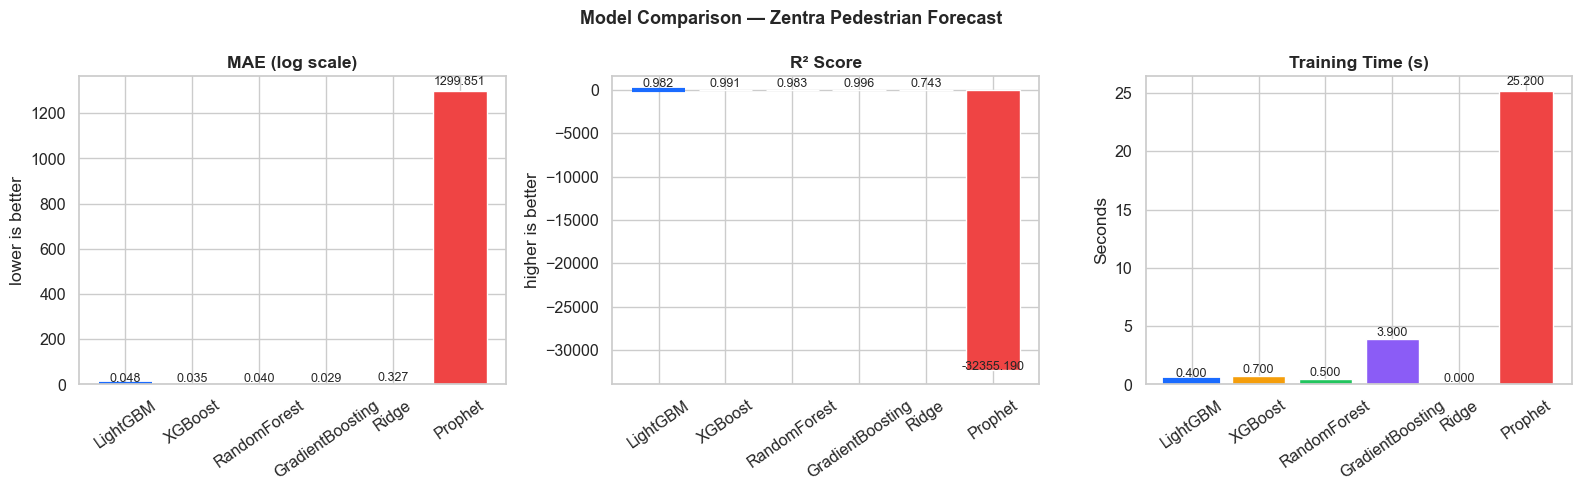

In [39]:
# Comparison table 
comparison = pd.DataFrame([
    {'Model': 'LightGBM', **lgb_metrics, 'Train_s': round(lgb_time, 1)},
    {'Model': 'XGBoost', **xgb_metrics, 'Train_s': round(xgb_time, 1)},
    {'Model': 'RandomForest', **rf_metrics, 'Train_s': round(rf_time, 1)},
    {'Model': 'GradientBoosting', **gb_metrics, 'Train_s': round(gb_time, 1)},
    {'Model': 'Ridge', **ridge_metrics, 'Train_s': round(ridge_time, 1)},
    {'Model': 'Prophet', **prophet_metrics, 'Train_s': round(prophet_time, 1)},
]).set_index('Model')
print(comparison[['MAE_log','RMSE_log','R2','Train_s']].to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cp = comparison.dropna(subset=['MAE_log'])
models = cp.index.tolist()
colors = [MODEL_COLORS.get(m, '#94a3b8') for m in models]
for ax, col, label, better in zip(axes,
    ['MAE_log','R2','Train_s'],
    ['MAE (log scale)','R² Score','Training Time (s)'],
    ['lower','higher','']):
    bars = ax.bar(models, cp[col], color=colors, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(f'{better} is better' if better else 'Seconds')
    ax.tick_params(axis='x', rotation=35)
    for bar, val in zip(bars, cp[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    for patch, m in zip(ax.patches, models):
        if m == 'LightGBM': patch.set_edgecolor(BLUE); patch.set_linewidth(3)
plt.suptitle('Model Comparison — Zentra Pedestrian Forecast', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Why LightGBM?

The Zentra dataset is heterogeneous tabular data with spatial features, temporal encodings,
structural missing values, and lag features — exactly where gradient boosting dominates.

| Alternative | Why it falls short |
|---|---|
| Ridge | Assumes linearity; can't model temp × period × location interactions |
| Random Forest | No residual learning; needs imputation; higher memory |
| Gradient Boosting (sklearn) | Same family, strictly slower than LightGBM |
| XGBoost | Comparable quality, slower training (LightGBM histogram wins) |
| Prophet | Temporal decomposition, not tabular feature regression |

## 5 · LightGBM Hyperparameter Tuning (Optuna)

In [40]:
def objective(trial):
    params = dict(
        objective = 'regression', metric='mae', verbosity=-1,
        n_estimators = trial.suggest_int('n_estimators', 200, 1000, step=100),
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        num_leaves = trial.suggest_int('num_leaves', 20, 127),
        max_depth = trial.suggest_int('max_depth', 4, 12),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 50),
        subsample = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        random_state=SEED, n_jobs=-1,
    )
    scores = cross_val_score(lgb.LGBMRegressor(**params), X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=1)
    return -scores.mean()

study = optuna.create_study(direction='minimize', study_name='zentra-lgbm')
study.optimize(objective, n_trials=60, show_progress_bar=True)

best_params = study.best_params
print(f'Best CV MAE : {study.best_value:.4f}')
print(json.dumps(best_params, indent=2))

Best trial: 55. Best value: 0.0936672: 100%|██████████| 60/60 [01:09<00:00,  1.15s/it]

Best CV MAE : 0.0937
{
  "n_estimators": 300,
  "learning_rate": 0.09257406914119487,
  "num_leaves": 56,
  "max_depth": 6,
  "min_child_samples": 7,
  "subsample": 0.6796182996449079,
  "colsample_bytree": 0.9803842412265006,
  "reg_alpha": 0.18337456688556267,
  "reg_lambda": 0.0009305228361905294
}


In [41]:
t0 = time.time()
lgb_tuned = lgb.LGBMRegressor(**{**best_params, 'objective':'regression','metric':'mae', 'random_state':SEED,'n_jobs':-1,'verbosity':-1})
lgb_tuned.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
tuned_pred = lgb_tuned.predict(X_test)
tuned_time = time.time() - t0
tuned_metrics = compute_metrics(y_test, tuned_pred, y_test_raw)
print(f'Tuned LightGBM ({tuned_time:.1f}s)  {tuned_metrics}')

Tuned LightGBM (0.1s)  {'MAE_log': 0.0537, 'RMSE_log': np.float64(0.1299), 'R2': 0.9724, 'MAPE_log': np.float64(0.7), 'MAE_raw': 231.0, 'RMSE_raw': np.float64(509.9)}


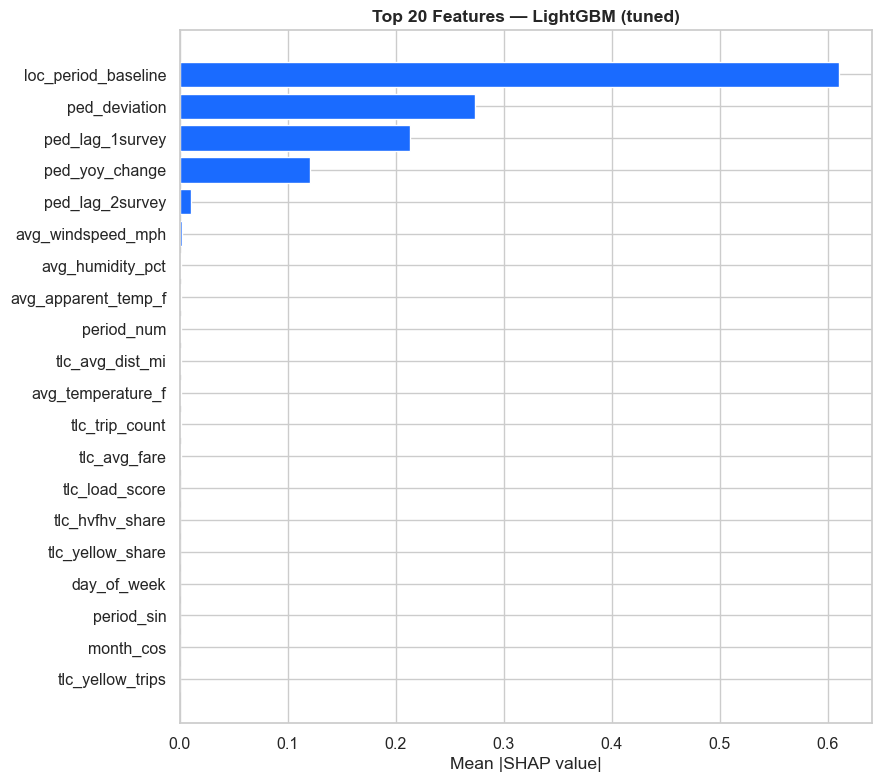

In [42]:
# SHAP feature importance
explainer = shap.TreeExplainer(lgb_tuned)
shap_vals = explainer.shap_values(X_test)
mean_shap = pd.Series(np.abs(shap_vals).mean(0), index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
top20 = mean_shap.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color=BLUE)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 20 Features — LightGBM (tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS / 'shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# Build prediction map for ensemble
prophet_pred_map = {
    (r['location_id'], r['period']): r['pred'] for _, r in prophet_df.iterrows()
}
print(f'Prophet pairs fitted: {len(prophet_df)}')

Prophet pairs fitted: 108


## 7 · Ensemble: LightGBM + Prophet

In [44]:
LGBM_WEIGHT = 0.70
PROPHET_WEIGHT = 0.30

ensemble_pred = tuned_pred.copy()  # fallback to LightGBM where Prophet unavailable
for i, (_, row) in enumerate(test_df.iterrows()):
    key = (row['location_id'], row['period'])
    if key in prophet_pred_map and len(prophet_pred_map[key]) > 0:
        prophet_val = prophet_pred_map[key][0]
        blended = LGBM_WEIGHT * tuned_pred[i] + PROPHET_WEIGHT * prophet_val
        # Only accept the blend if it's finite and in a plausible log range
        if np.isfinite(blended) and 0 <= blended <= 15:
            ensemble_pred[i] = blended
        # else: keep tuned LightGBM prediction as fallback

# Sanity check
n_inf = np.isinf(ensemble_pred).sum()
n_nan = np.isnan(ensemble_pred).sum()
if n_inf > 0 or n_nan > 0:
    print(f'WARNING: {n_inf} inf, {n_nan} NaN in ensemble_pred — falling back to tuned_pred for those rows')
    ensemble_pred = np.where(np.isfinite(ensemble_pred), ensemble_pred, tuned_pred)

ensemble_metrics = compute_metrics(y_test, ensemble_pred, y_test_raw)
print(f'Ensemble ({LGBM_WEIGHT:.0%} LGB + {PROPHET_WEIGHT:.0%} Prophet)  {ensemble_metrics}')

Ensemble (70% LGB + 30% Prophet)  {'MAE_log': 0.0537, 'RMSE_log': np.float64(0.1299), 'R2': 0.9724, 'MAPE_log': np.float64(0.7), 'MAE_raw': 231.0, 'RMSE_raw': np.float64(509.9)}


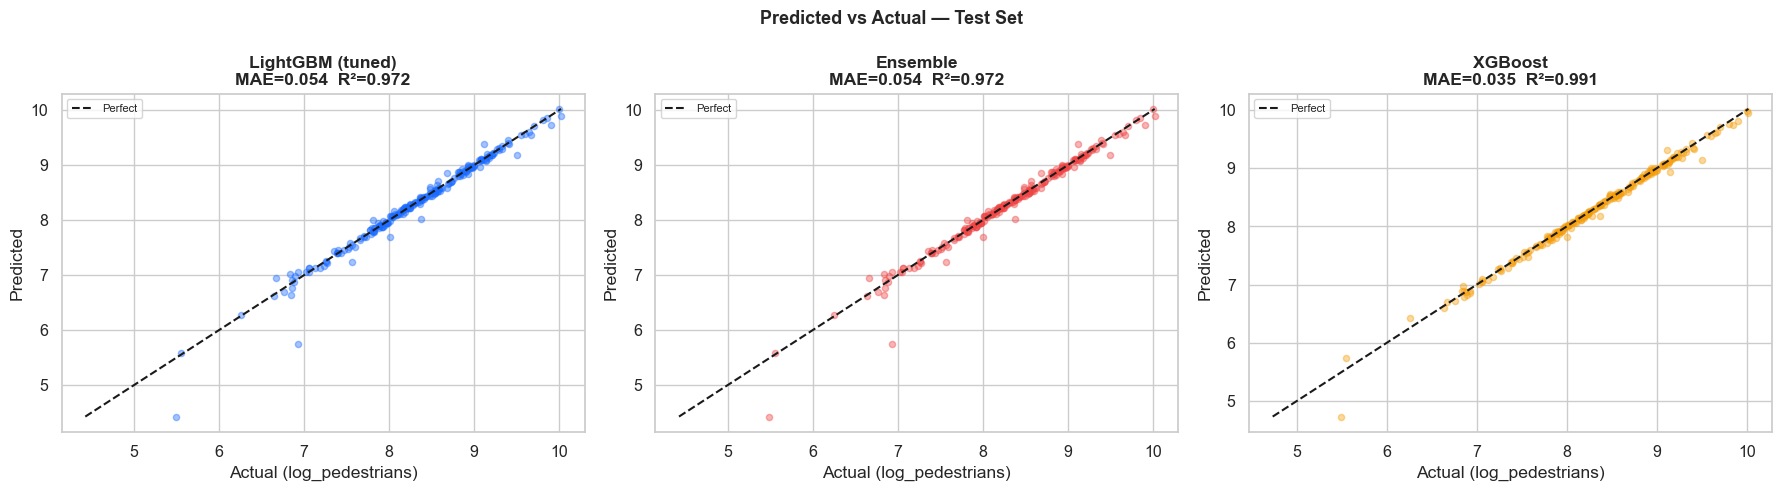

In [45]:
# Predicted vs Actual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, preds, color) in zip(axes, [
    ('LightGBM (tuned)', tuned_pred, BLUE),
    ('Ensemble', ensemble_pred, RED),
    ('XGBoost', xgb_pred, ORANGE),
]):
    ax.scatter(y_test, preds, alpha=0.4, s=20, color=color)
    mn, mx = min(y_test.min(), preds.min()), max(y_test.max(), preds.max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect')
    m = compute_metrics(y_test, preds)
    ax.set_title(f'{name}\nMAE={m["MAE_log"]:.3f}  R²={m["R2"]:.3f}', fontweight='bold')
    ax.set_xlabel('Actual (log_pedestrians)'); ax.set_ylabel('Predicted'); ax.legend(fontsize=8)
plt.suptitle('Predicted vs Actual — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS / 'pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

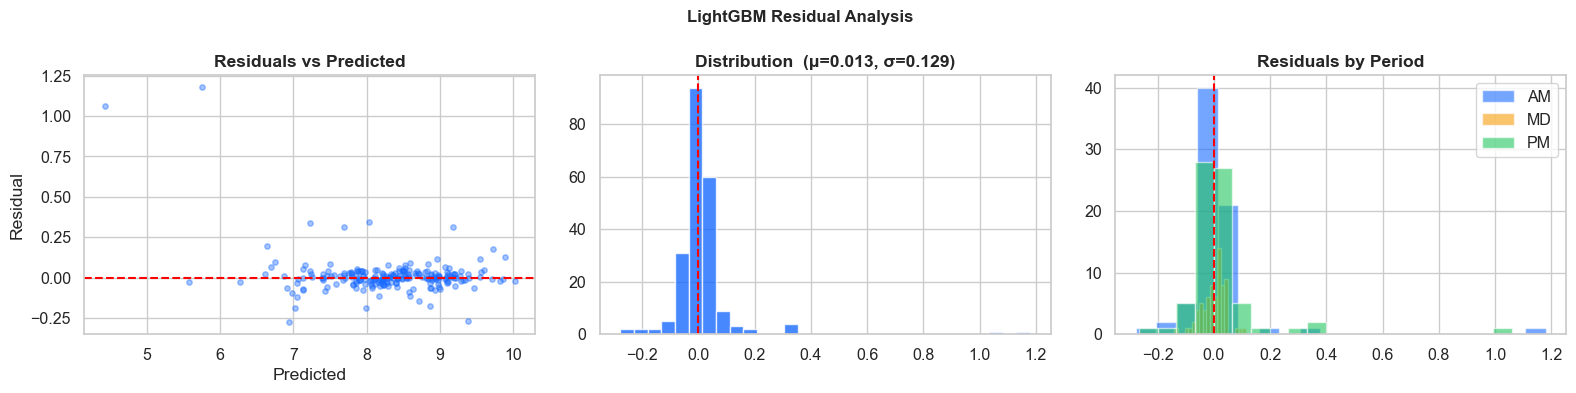

In [46]:
# Residual analysis
residuals = y_test.values - tuned_pred
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(tuned_pred, residuals, alpha=0.4, s=15, color=BLUE)
axes[0].axhline(0, color='red', lw=1.5, ls='--')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')

axes[1].hist(residuals, bins=30, color=BLUE, edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', lw=1.5, ls='--')
axes[1].set_title(f'Distribution  (μ={residuals.mean():.3f}, σ={residuals.std():.3f})', fontweight='bold')

period_res = pd.DataFrame({'period': test_df['period'].values, 'residual': residuals})
for period, c in [('AM', BLUE),('MD', ORANGE),('PM', GREEN)]:
    axes[2].hist(period_res[period_res['period']==period]['residual'], bins=20, alpha=0.6, label=period, color=c, edgecolor='white')
axes[2].axvline(0, color='red', lw=1.5, ls='--')
axes[2].set_title('Residuals by Period', fontweight='bold'); axes[2].legend()

plt.suptitle('LightGBM Residual Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS / 'residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
# Per-location accuracy
test_eval = test_df.assign(y_pred=tuned_pred, residual=y_test.values - tuned_pred)
loc_acc = (
    test_eval.groupby('location_id')
    .apply(lambda g: pd.Series({
        'MAE'   : mean_absolute_error(g[TARGET], g['y_pred']),
        'R2'    : r2_score(g[TARGET], g['y_pred']),
        'n_rows': len(g),
        'street': g['street'].iloc[0],
    }))
    .sort_values('MAE')
)
print('Best 10:', loc_acc.head(10)[['street','MAE','R2']].to_string())
print('Worst 5:', loc_acc.tail(5)[['street','MAE','R2']].to_string())

Best 10:                        street   MAE    R2
location_id                              
44              Eighth Avenue 0.013 0.999
69              Eighth Avenue 0.013 0.999
41           East 14th Street 0.014 0.999
35               Broad Street 0.015 0.998
63                Park Avenue 0.015 0.999
40            Delancey Street 0.016 0.998
55           West 14th Street 0.018 0.997
36                   Broadway 0.018 0.998
47              Fulton Street 0.021 0.993
64             Madison Avenue 0.023 0.997
Worst 5:                             street   MAE    R2
location_id                                   
43                 East 8th Street 0.113 0.946
52                   Trinity Place 0.122 0.770
51                  Seventh Avenue 0.131 0.855
70           Hudson River Greenway 0.237 0.489
68                        Broadway 0.270 0.573


## 8 · Export — Model, Metrics & Artefacts

In [ ]:
from prophet.serialize import model_to_json

# Save LightGBM 
model_path = MODELS / 'lgbm_tuned.txt'
lgb_tuned.booster_.save_model(str(model_path))
print(f'LightGBM → {model_path}')

# Save Prophet models 
PROPHET_DIR = MODELS / 'prophet'
PROPHET_DIR.mkdir(exist_ok=True)

class _NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if hasattr(obj, 'item'):
            return obj.item()
        return super().default(obj)

prophet_coverage = []
for row in prophet_rows:
    fname = f"prophet_{int(row['location_id'])}_{row['period']}.json"
    fpath = PROPHET_DIR / fname
    with open(fpath, 'w') as f:
        json.dump(model_to_json(row['model']), f)
    prophet_coverage.append({
        'location_id': int(row['location_id']),
        'period':      str(row['period']),
        'model_file':  f'prophet/{fname}',
        'mae_log':     float(round(row['mae'], 4)),
        'r2':          float(round(row['r2'],  4)),
    })

print(f'Prophet  → {PROPHET_DIR}  ({len(prophet_coverage)} models)')

# Save ensemble artefact 
ensemble_artefact = {
    'lgbm_model':       'lgbm_tuned.txt',
    'lgbm_weight':      LGBM_WEIGHT,
    'prophet_weight':   PROPHET_WEIGHT,
    'prophet_regs':     PROPHET_REGS,
    'prophet_coverage': prophet_coverage,
    'fallback':         'lgbm_only',
}
ensemble_path = MODELS / 'ensemble_config.json'
ensemble_path.write_text(json.dumps(ensemble_artefact, indent=2, cls=_NpEncoder))
print(f'Ensemble → {ensemble_path}')

# Metrics & params 
metrics_report = {
    'LightGBM_tuned':   tuned_metrics,
    'LightGBM_default': lgb_metrics,
    'Ensemble':         ensemble_metrics,
    'XGBoost':          xgb_metrics,
    'RandomForest':     rf_metrics,
    'GradientBoosting': gb_metrics,
    'Ridge':            ridge_metrics,
    'Prophet':          prophet_metrics,
}
(REPORTS / 'metrics.json').write_text(json.dumps(metrics_report, indent=2, cls=_NpEncoder))
(REPORTS / 'best_params.json').write_text(json.dumps(best_params, indent=2, cls=_NpEncoder))
print(f'Metrics  → {REPORTS / "metrics.json"}')
print(f'Params   → {REPORTS / "best_params.json"}')

LightGBM → D:\Projects\Zentra\zentra-ml\models\lgbm_tuned.txt
Prophet  → D:\Projects\Zentra\zentra-ml\models\prophet  (108 models)
Ensemble → D:\Projects\Zentra\zentra-ml\models\ensemble_config.json
Metrics  → D:\Projects\Zentra\zentra-ml\reports\metrics.json
Params   → D:\Projects\Zentra\zentra-ml\reports\best_params.json
